# Análisis exploratorio y modelo predictivo: Online Retail II

Dataset de transacciones de un retailer online del Reino Unido (dic-2009 a dic-2011).  
El objetivo es entender el comportamiento de los clientes y predecir la probabilidad de recompra.

**Contenido:**
1. Carga de datos
2. Primera inspección
3. Calidad de datos
4. Limpieza de datos
5. Estadísticas descriptivas
6. Visualizaciones
7. Agrupación por cliente (RFM)
8. Modelo: probabilidad de recompra
9. Explicabilidad del modelo

In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

In [3]:
# Ruta al dataset
DATA_PATH = r'D:\DataScience\Proyecto-5-MachineLearning\Databases\online_retail_II.xlsx'

xl = pd.ExcelFile(DATA_PATH)
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Filas: 1,067,371 | Columnas: 8


## 2. Primera inspección

In [4]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,"13,085.00",United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,"13,085.00",United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,"13,085.00",United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,"13,085.00",United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


## 3. Calidad de datos

Antes de limpiar, inspeccionamos los problemas presentes en el dataset:
- **Nulos**: `Customer ID` tiene un 22.77% de nulos — no podemos modelar sin identificador de cliente
- **Duplicados**: filas completamente idénticas
- **Facturas canceladas**: `Invoice` que empieza por `C` — representan devoluciones
- **Anomalías**: `Quantity <= 0` y `Price <= 0` fuera de cancelaciones

In [6]:
# Nulos por columna
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
print(pd.DataFrame({'Nulos': nulos, '% Nulos': nulos_pct}).to_string())

              Nulos  % Nulos
Invoice           0     0.00
StockCode         0     0.00
Description    4382     0.41
Quantity          0     0.00
InvoiceDate       0     0.00
Price             0     0.00
Customer ID  243007    22.77
Country           0     0.00


In [7]:
# Duplicados
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {n_duplicados:,} ({n_duplicados/len(df)*100:.2f}%)')

Filas duplicadas: 34,335 (3.22%)


In [8]:
# Facturas canceladas (Invoice empieza por 'C')
canceladas = df[df['Invoice'].astype(str).str.startswith('C')]
print(f'Facturas canceladas: {len(canceladas):,} ({len(canceladas)/len(df)*100:.2f}%)')
print(f'Clientes únicos con cancelaciones: {canceladas["Customer ID"].nunique():,}')

Facturas canceladas: 19,494 (1.83%)
Clientes únicos con cancelaciones: 2,572


In [9]:
# Precios y cantidades negativos o cero (fuera de cancelaciones)
no_cancel = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f'Quantity <= 0 (sin cancelaciones): {(no_cancel["Quantity"] <= 0).sum():,}')
print(f'Price <= 0: {(no_cancel["Price"] <= 0).sum():,}')
print(f'Sin Customer ID: {no_cancel["Customer ID"].isnull().sum():,} ({no_cancel["Customer ID"].isnull().mean()*100:.2f}%)')

Quantity <= 0 (sin cancelaciones): 3,457
Price <= 0: 6,207
Sin Customer ID: 242,257 (23.12%)


## 4. Limpieza de datos

Aplicamos los siguientes filtros en orden:
1. Eliminar duplicados exactos
2. Eliminar facturas canceladas (`Invoice` empieza por `C`)
3. Eliminar registros sin `Customer ID` (no identificables)
4. Eliminar `Quantity <= 0` y `Price <= 0`
5. Convertir `Customer ID` a entero

Se guarda `df_raw` antes de limpiar para poder calcular features sobre cancelaciones más adelante.

In [10]:
print(f'Filas originales: {len(df):,}')

# Guardar copia del dataset original antes de cualquier limpieza
df_raw = df.copy()

# 1. Eliminar duplicados
df = df.drop_duplicates()
print(f'Tras eliminar duplicados: {len(df):,}')

# 2. Eliminar facturas canceladas (Invoice empieza por 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f'Tras eliminar cancelaciones: {len(df):,}')

# 3. Eliminar registros sin Customer ID
df = df[df['Customer ID'].notna()]
print(f'Tras eliminar sin Customer ID: {len(df):,}')

# 4. Eliminar Quantity <= 0 y Price <= 0
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f'Tras eliminar Quantity/Price anómalos: {len(df):,}')

# 5. Convertir Customer ID a int (es un identificador numérico)
df['Customer ID'] = df['Customer ID'].astype(int)

print(f'\nFilas eliminadas en total: {1_067_371 - len(df):,} ({(1 - len(df)/1_067_371)*100:.1f}%)')
print(f'\nTipos tras limpieza:')
print(df.dtypes)

Filas originales: 1,067,371
Tras eliminar duplicados: 1,033,036
Tras eliminar cancelaciones: 1,013,932
Tras eliminar sin Customer ID: 779,495
Tras eliminar Quantity/Price anómalos: 779,425

Filas eliminadas en total: 287,946 (27.0%)

Tipos tras limpieza:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country                object
dtype: object


## 5. Estadísticas descriptivas

Calculamos `Revenue = Quantity × Price` y analizamos la distribución de las variables clave.  
El dataset abarca **738 días** (dic-2009 a dic-2011) con transacciones en libras esterlinas (£).

In [11]:
# Rango de fechas del dataset
print(f'Fecha inicio: {df["InvoiceDate"].min().date()}')
print(f'Fecha fin:    {df["InvoiceDate"].max().date()}')
print(f'Periodo:      {(df["InvoiceDate"].max() - df["InvoiceDate"].min()).days} días')

Fecha inicio: 2009-12-01
Fecha fin:    2011-12-09
Periodo:      738 días


In [12]:
# Calcular Revenue
df['Revenue'] = df['Quantity'] * df['Price']

# Estadísticas descriptivas de las variables clave
display(df[['Quantity', 'Price', 'Revenue']].describe().round(2))

# Investigar Price = 0 tras la limpieza
precio_cero = df[df['Price'] == 0]
print(f'\nRegistros con Price = 0 tras limpieza: {len(precio_cero):,}')
if len(precio_cero) > 0:
    print(precio_cero[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']].head())

,Quantity,Price,Revenue
count,"779,425.00","779,425.00","779,425.00"
mean,13.49,3.22,22.29
std,145.86,29.68,227.43
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,6.00,1.95,12.48
75%,12.00,3.75,19.80
max,"80,995.00","10,953.50","168,469.60"



Registros con Price = 0 tras limpieza: 0


## 6. Visualizaciones

Exploramos tres dimensiones clave:
- **Temporal**: evolución mensual del revenue (¿hay estacionalidad?)
- **Geográfica**: qué países generan más revenue (con y sin UK para ver el resto del mundo)
- **Comportamiento**: distribución de facturas por cliente y % de clientes que repiten

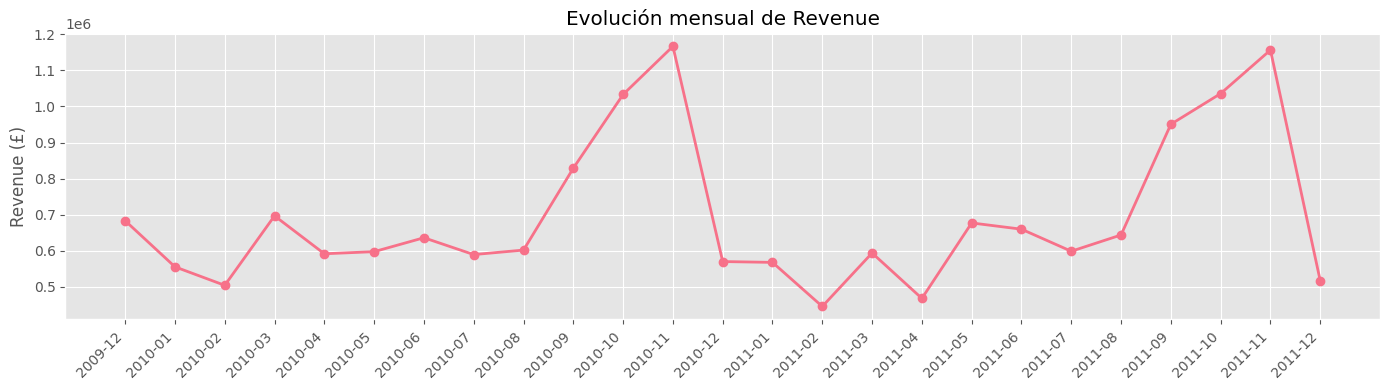

In [13]:
# Evolución mensual de ventas
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
ventas_mes = df.groupby('YearMonth')['Revenue'].sum().reset_index()
ventas_mes['YearMonth'] = ventas_mes['YearMonth'].astype(str)

plt.figure(figsize=(14, 4))
plt.plot(ventas_mes['YearMonth'], ventas_mes['Revenue'], marker='o', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Evolución mensual de Revenue')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

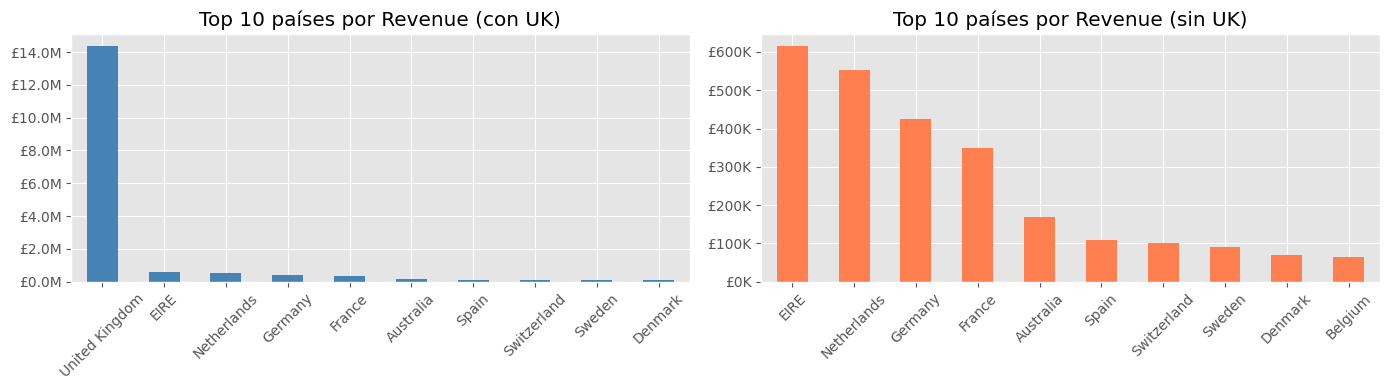

In [14]:
# Top 10 países por revenue
top_paises = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Con UK
top_paises.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 países por Revenue (con UK)')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=45)

# Sin UK
top_paises_sin_uk = df[df['Country'] != 'United Kingdom'].groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
top_paises_sin_uk.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 países por Revenue (sin UK)')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

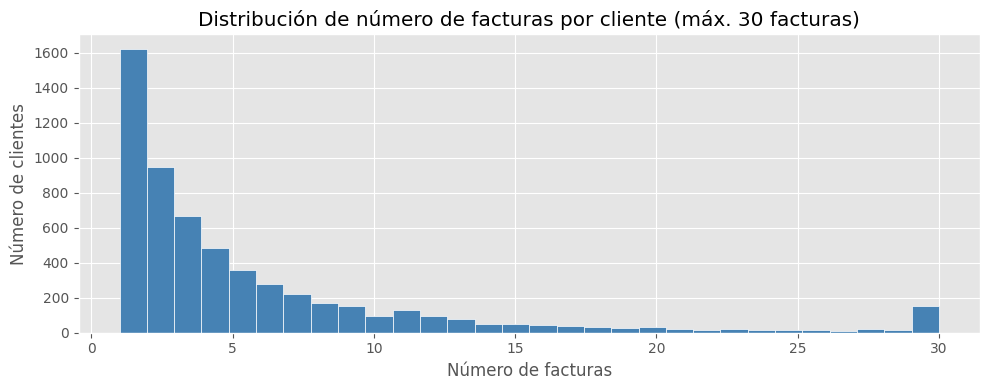

count   5,878.00
mean        6.29
std        13.01
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       398.00
Name: Invoice, dtype: float64


In [15]:
# Distribución de facturas por cliente (frecuencia de compra)
facturas_cliente = df.groupby('Customer ID')['Invoice'].nunique()

plt.figure(figsize=(10, 4))
facturas_cliente.clip(upper=30).hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución de número de facturas por cliente (máx. 30 facturas)')
plt.xlabel('Número de facturas')
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.show()

print(facturas_cliente.describe().round(2))

In [16]:
# % clientes que repiten compra
clientes_facturas = df.groupby('Customer ID')['Invoice'].nunique()
clientes_repiten = (clientes_facturas > 1).sum()
clientes_total = clientes_facturas.count()

print(f'Clientes totales:        {clientes_total:,}')
print(f'Clientes que repiten:    {clientes_repiten:,} ({clientes_repiten/clientes_total*100:.1f}%)')
print(f'Clientes que no repiten: {clientes_total - clientes_repiten:,} ({(clientes_total - clientes_repiten)/clientes_total*100:.1f}%)')

Clientes totales:        5,878
Clientes que repiten:    4,255 (72.4%)
Clientes que no repiten: 1,623 (27.6%)


## 7. Agrupación por cliente (RFM)

Construimos un perfil por cliente basado en métricas **RFM**:
- **R** (Recency): días desde la última compra hasta el fin del dataset
- **F** (Frequency): número de facturas distintas
- **M** (Monetary): revenue total y ticket medio

Esta agregación es la base del modelo predictivo de la sección 8.

In [17]:
# Agrupación por cliente
clientes = df.groupby('Customer ID').agg(
    revenue_total    = ('Revenue', 'sum'),
    n_facturas       = ('Invoice', 'nunique'),
    ultima_compra    = ('InvoiceDate', 'max'),
    pais             = ('Country', lambda x: x.mode()[0])  # país más frecuente del cliente
).reset_index()

# Ticket medio
clientes['ticket_medio'] = clientes['revenue_total'] / clientes['n_facturas']

# Recencia: días desde la última compra hasta el fin del dataset
fecha_max = df['InvoiceDate'].max()
clientes['recencia_dias'] = (fecha_max - clientes['ultima_compra']).dt.days

clientes = clientes.drop(columns='ultima_compra')

print(f'Clientes únicos: {len(clientes):,}')
clientes.describe().round(2)


Clientes únicos: 5,878


,Customer ID,revenue_total,n_facturas,ticket_medio,recencia_dias
count,"5,878.00","5,878.00","5,878.00","5,878.00","5,878.00"
mean,"15,315.31","2,955.90",6.29,385.18,200.33
std,"1,715.57","14,440.85",13.01,"1,214.29",209.34
min,"12,346.00",2.95,1.00,2.95,0.00
25%,"13,833.25",342.28,1.00,176.68,25.00
50%,"15,314.50",867.74,3.00,279.24,95.00
75%,"16,797.75","2,248.30",7.00,414.90,379.00
max,"18,287.00","580,987.04",398.00,"84,236.25",738.00


In [18]:
# Insights sobre la agrupación por cliente
print("--- Revenue total ---")
print(f"  Media:   £{clientes['revenue_total'].mean():,.0f} | Máximo: £{clientes['revenue_total'].max():,.0f}")
print(f"  El 25% de clientes gasta menos de £{clientes['revenue_total'].quantile(0.25):,.0f}")

print("\n--- Frecuencia de compra ---")
print(f"  Media: {clientes['n_facturas'].mean():.1f} facturas | Mediana: {clientes['n_facturas'].median():.0f} | Máximo: {clientes['n_facturas'].max():.0f}")

print("\n--- Recencia ---")
print(f"  Mediana: {clientes['recencia_dias'].median():.0f} días sin comprar")
print(f"  Máximo:  {clientes['recencia_dias'].max():.0f} días (clientes que solo compraron al inicio del periodo)")

print("\n--- Ticket medio ---")
print(f"  Media: £{clientes['ticket_medio'].mean():,.0f} | Máximo: £{clientes['ticket_medio'].max():,.0f} (posible B2B)")

--- Revenue total ---
  Media:   £2,956 | Máximo: £580,987
  El 25% de clientes gasta menos de £342

--- Frecuencia de compra ---
  Media: 6.3 facturas | Mediana: 3 | Máximo: 398

--- Recencia ---
  Mediana: 95 días sin comprar
  Máximo:  738 días (clientes que solo compraron al inicio del periodo)

--- Ticket medio ---
  Media: £385 | Máximo: £84,236 (posible B2B)


## 8. Modelo: probabilidad de recompra

Modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte.

Estrategia:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos tres modelos y comparamos su rendimiento:
  - **Regresión Logística** — baseline, simple e interpretable.
  - **Random Forest** — conjunto de árboles de decisión, más robusto.
  - **XGBoost** — boosting, generalmente el más potente en datos tabulares.
- Para cada modelo aplicamos **Optuna** para buscar los mejores hiperparámetros.
- Evaluamos con **Matriz de Confusión**, **Classification Report** y **ROC-AUC**.

### Preparación del dataset para el modelo

El pipeline de preparación sigue estos pasos:
1. **Fecha de corte** → dividir el dataset en periodo de observación (antes) y periodo de etiqueta (después)
2. **Feature engineering** → construir 13 variables por cliente con datos anteriores al corte (RFM + comportamentales)
3. **Variable objetivo** → si el cliente compró después del corte: `recompra = 1`, si no: `recompra = 0`
4. **Transformaciones** → log-transform en variables sesgadas + One-Hot Encoding para el país
5. **Train/Test split** → 80/20 estratificado + StandardScaler

In [19]:
pip install optuna xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# ── 8.1 Fecha de corte ────────────────────────────────────────────────────────
# El dataset va de dic-2009 a dic-2011 (738 días).
# Usamos sept-2011 como corte: ~3 meses de ventana de observación para la etiqueta.

CUTOFF = pd.Timestamp('2011-09-01')

df_antes  = df[df['InvoiceDate'] <  CUTOFF]
df_despues = df[df['InvoiceDate'] >= CUTOFF]

print(f'Periodo ANTES  del corte: {df_antes["InvoiceDate"].min().date()} → {df_antes["InvoiceDate"].max().date()} | {len(df_antes):,} filas')
print(f'Periodo DESPUÉS del corte: {df_despues["InvoiceDate"].min().date()} → {df_despues["InvoiceDate"].max().date()} | {len(df_despues):,} filas')
print(f'Clientes únicos ANTES: {df_antes["Customer ID"].nunique():,}')
print(f'Clientes únicos DESPUÉS: {df_despues["Customer ID"].nunique():,}')

Periodo ANTES  del corte: 2009-12-01 → 2011-08-31 | 610,768 filas
Periodo DESPUÉS del corte: 2011-09-01 → 2011-12-09 | 168,657 filas
Clientes únicos ANTES: 5,249
Clientes únicos DESPUÉS: 2,973


In [21]:
# ── 8.2 Construcción de features por cliente (datos ANTES del corte) ──────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ── Revenue neto: descontamos devoluciones desde df_raw ──────────────────────
df_raw['Revenue'] = df_raw['Quantity'] * df_raw['Price']
df_raw_antes = df_raw[df_raw['InvoiceDate'] < CUTOFF].copy()
df_raw_antes['es_cancelacion'] = df_raw_antes['Invoice'].astype(str).str.startswith('C')

revenue_neto = (
    df_raw_antes[df_raw_antes['Customer ID'].notna()]
    .groupby('Customer ID')['Revenue']
    .sum()
    .rename('revenue_neto')
)

cancelaciones_raw = df_raw_antes[df_raw_antes['es_cancelacion'] & df_raw_antes['Customer ID'].notna()]
compras_raw       = df_raw_antes[~df_raw_antes['es_cancelacion'] & df_raw_antes['Customer ID'].notna()]
n_cancelaciones   = cancelaciones_raw.groupby('Customer ID')['Invoice'].nunique()
n_compras         = compras_raw.groupby('Customer ID')['Invoice'].nunique()
ratio_cancelaciones = (n_cancelaciones / (n_compras + n_cancelaciones)).fillna(0).rename('ratio_cancelaciones')

# ── Features básicas RFM ──────────────────────────────────────────────────────
clientes_model = df_antes.groupby('Customer ID').agg(
    revenue_total  = ('Revenue', 'sum'),
    n_facturas     = ('Invoice', 'nunique'),
    ultima_compra  = ('InvoiceDate', 'max'),
    pais           = ('Country', lambda x: x.mode()[0])
).reset_index()

clientes_model['ticket_medio']  = clientes_model['revenue_total'] / clientes_model['n_facturas']
clientes_model['recencia_dias'] = (CUTOFF - clientes_model['ultima_compra']).dt.days
clientes_model = clientes_model.drop(columns='ultima_compra')

# ── Features adicionales ──────────────────────────────────────────────────────

# Número de productos distintos comprados
productos_distintos = df_antes.groupby('Customer ID')['StockCode'].nunique().rename('n_productos_distintos')

# Precio medio de los productos que compra el cliente
precio_medio = df_antes.groupby('Customer ID')['Price'].mean().rename('precio_medio_producto')

# Cantidad media por línea de factura
cantidad_media = df_antes.groupby('Customer ID')['Quantity'].mean().rename('cantidad_media_linea')

# Días medios entre compras consecutivas
def dias_entre_compras(fechas):
    fechas_ord = sorted(fechas)
    if len(fechas_ord) < 2:
        return 0
    diffs = [(fechas_ord[i+1] - fechas_ord[i]).days for i in range(len(fechas_ord)-1)]
    return np.mean(diffs)

intervalo_compras = df_antes.groupby('Customer ID')['InvoiceDate'].apply(
    dias_entre_compras
).rename('intervalo_medio_dias')

# Tendencia de gasto: media revenue últimas 3 facturas vs primeras 3
def tendencia_gasto(grupo):
    facturas = grupo.groupby('Invoice')['Revenue'].sum().sort_index()
    if len(facturas) < 4:
        return 0
    return facturas.iloc[-3:].mean() - facturas.iloc[:3].mean()

tendencia = df_antes.groupby('Customer ID').apply(
    tendencia_gasto, include_groups=False
).rename('tendencia_gasto')

# ¿Compra en diciembre? (Navidad)
compra_navidad = df_antes.assign(
    es_diciembre=df_antes['InvoiceDate'].dt.month.eq(12).astype(int)
).groupby('Customer ID')['es_diciembre'].max().rename('compra_navidad')

# Revenue de la última factura
revenue_ultima = (
    df_antes.groupby(['Customer ID', 'Invoice'])['Revenue'].sum()
    .reset_index()
    .sort_values('Invoice')
    .groupby('Customer ID')['Revenue']
    .last()
    .rename('revenue_ultima_factura')
)

# Número de meses distintos en los que ha comprado
meses_activo = df_antes.assign(
    anio_mes=df_antes['InvoiceDate'].dt.to_period('M')
).groupby('Customer ID')['anio_mes'].nunique().rename('meses_activo')

# Unir todas las features
clientes_model = clientes_model.merge(revenue_neto,         on='Customer ID', how='left')
clientes_model = clientes_model.merge(productos_distintos,  on='Customer ID', how='left')
clientes_model = clientes_model.merge(precio_medio,         on='Customer ID', how='left')
clientes_model = clientes_model.merge(cantidad_media,       on='Customer ID', how='left')
clientes_model = clientes_model.merge(intervalo_compras,    on='Customer ID', how='left')
clientes_model = clientes_model.merge(tendencia,            on='Customer ID', how='left')
clientes_model = clientes_model.merge(compra_navidad,       on='Customer ID', how='left')
clientes_model = clientes_model.merge(revenue_ultima,       on='Customer ID', how='left')
clientes_model = clientes_model.merge(ratio_cancelaciones,  on='Customer ID', how='left')
clientes_model = clientes_model.merge(meses_activo,         on='Customer ID', how='left')

clientes_model['ratio_cancelaciones'] = clientes_model['ratio_cancelaciones'].fillna(0)
clientes_model['revenue_neto']        = clientes_model['revenue_neto'].fillna(0)

print(f'Clientes con historial antes del corte: {len(clientes_model):,}')
print(f'Features disponibles: {len(clientes_model.columns) - 2}')
clientes_model.head()

Clientes con historial antes del corte: 5,249
Features disponibles: 14


,Customer ID,revenue_total,n_facturas,pais,ticket_medio,recencia_dias,revenue_neto,n_productos_distintos,precio_medio_producto,cantidad_media_linea,intervalo_medio_dias,tendencia_gasto,compra_navidad,revenue_ultima_factura,ratio_cancelaciones,meses_activo
0,12346,"77,556.46",12,United Kingdom,"6,463.04",225,-64.68,27,6.10,"2,184.85",11.97,"25,754.32",1,"77,183.60",0.29,5
1,12347,"3,402.39",6,Iceland,567.07,29,"4,114.18",107,2.56,12.80,1.67,-65.01,1,584.91,0.00,6
2,12348,"1,709.40",4,Finland,427.35,148,"1,709.40",25,3.14,52.02,4.02,48.28,1,367.00,0.00,4
3,12349,"2,671.14",3,Italy,890.38,307,"2,646.99",90,8.58,9.74,1.78,0.00,0,"1,402.62",0.25,3
4,12350,334.40,1,Norway,334.40,210,334.40,17,3.84,11.59,0.00,0.00,0,334.40,0.00,1


In [22]:
# ── 8.3 Variable objetivo + transformaciones + definición de X e y ────────────

# Variable objetivo: ¿compró después del corte?
clientes_recompran = set(df_despues['Customer ID'].unique())
clientes_model['recompra'] = clientes_model['Customer ID'].isin(clientes_recompran).astype(int)

# Log-transform en variables con mucho sesgo (outliers B2B)
clientes_model['log_revenue']        = np.log1p(clientes_model['revenue_total'])
clientes_model['log_revenue_neto']   = np.log1p(clientes_model['revenue_neto'].clip(lower=0))
clientes_model['log_ticket']         = np.log1p(clientes_model['ticket_medio'])
clientes_model['log_productos']      = np.log1p(clientes_model['n_productos_distintos'])
clientes_model['log_revenue_ultima'] = np.log1p(clientes_model['revenue_ultima_factura'])

TARGET      = 'recompra'
FEATURE_CAT = 'pais'

FEATURES_FINAL = [
    'log_revenue',            # Gasto total bruto (log)
    'log_revenue_neto',       # Gasto neto descontando devoluciones (log)
    'n_facturas',             # Frecuencia de compra
    'log_ticket',             # Ticket medio (log)
    'recencia_dias',          # Días desde última compra al corte
    'log_productos',          # Nº productos distintos (log)
    'precio_medio_producto',  # ¿Cliente premium o económico?
    'cantidad_media_linea',   # Unidades medias por línea
    'intervalo_medio_dias',   # Regularidad entre compras
    'tendencia_gasto',        # ¿Gasta más en sus últimas compras?
    'compra_navidad',         # ¿Compra en diciembre?
    'log_revenue_ultima',     # Revenue de la última factura (log)
    'ratio_cancelaciones',    # % de facturas que fueron canceladas
    'meses_activo'            # Nº de meses distintos con compras
]

# One-Hot Encoding del país
X_cat = pd.get_dummies(clientes_model[FEATURE_CAT], prefix='pais', drop_first=True)
X_num = clientes_model[FEATURES_FINAL]
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
y = clientes_model[TARGET]

# Balance de clases
vc = clientes_model['recompra'].value_counts()
print(f'Recompra  1 (sí): {vc[1]:,} ({vc[1]/len(clientes_model)*100:.1f}%)')
print(f'Recompra  0 (no): {vc[0]:,} ({vc[0]/len(clientes_model)*100:.1f}%)')
print(f'\nFeatures numéricas: {len(FEATURES_FINAL)}  |  OHE países: {X_cat.shape[1]}  |  Total: {X.shape[1]}')

Recompra  1 (sí): 2,344 (44.7%)
Recompra  0 (no): 2,905 (55.3%)

Features numéricas: 14  |  OHE países: 40  |  Total: 54


In [23]:
# ── 8.5 Train / Test split + Escalado ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape[0]:,} | Test: {X_test_sc.shape[0]:,}')
print(f'% recompra train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%')

Train: 4,199 | Test: 1,050
% recompra train: 44.7%  |  test: 44.7%


### Modelo 1: Regresión Logística (baseline)

Modelo más sencillo. Aprende relaciones lineales entre las features y la probabilidad de recompra.  
Se usa como **baseline** — punto de referencia mínimo que los modelos más complejos deben superar.

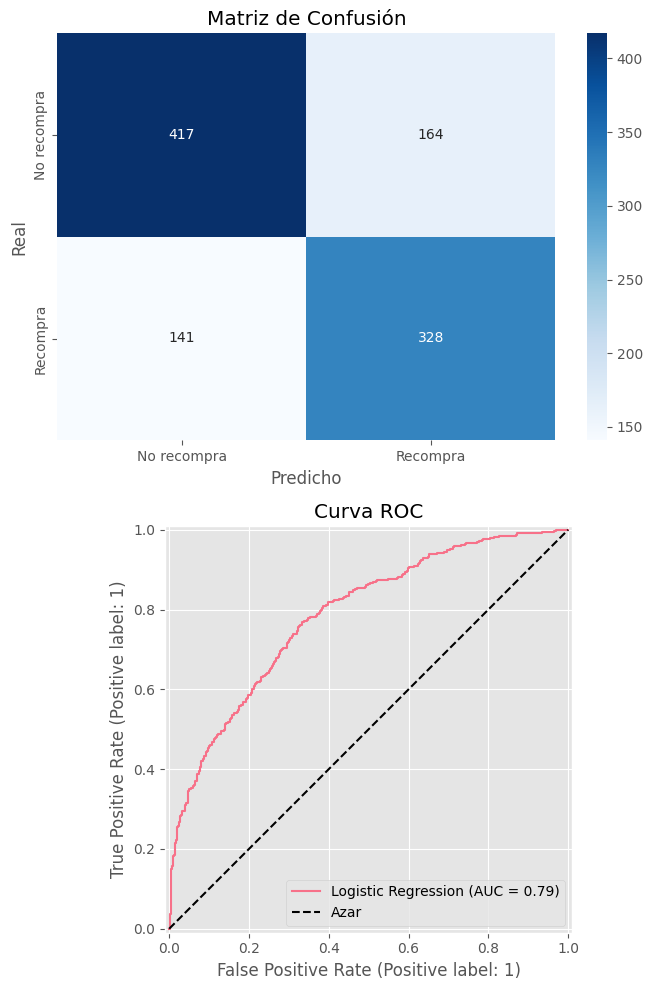


ROC-AUC: 0.7853

Classification Report:
              precision    recall  f1-score   support

 No recompra       0.75      0.72      0.73       581
    Recompra       0.67      0.70      0.68       469

    accuracy                           0.71      1050
   macro avg       0.71      0.71      0.71      1050
weighted avg       0.71      0.71      0.71      1050



In [24]:
# ── 8.6 Regresión Logística (baseline) ────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

# class_weight='balanced' para compensar el desbalance de clases
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_lr.fit(X_train_sc, y_train)

y_pred      = model_lr.predict(X_test_sc)
y_pred_prob = model_lr.predict_proba(X_test_sc)[:, 1]

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(2, 1, figsize=(7, 10))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No recompra', 'Recompra'],
            yticklabels=['No recompra', 'Recompra'])
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1], name='Logistic Regression')
axes[1].set_title('Curva ROC')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].legend()

plt.tight_layout()
plt.show()

# Métricas
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'\nROC-AUC: {roc_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No recompra', 'Recompra']))

In [25]:
# ── (Opcional) Búsqueda de hiperparámetros con Optuna — Regresión Logística ────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Hiperparámetros que Optuna va a explorar
    C        = trial.suggest_float('C', 1e-4, 1e4, log=True)
    solver   = trial.suggest_categorical('solver', ['lbfgs', 'saga'])
    max_iter = trial.suggest_categorical('max_iter', [500, 1000, 2000])
    penalty  = trial.suggest_categorical('penalty', ['l2', None])

    model = LogisticRegression(
        C=C, solver=solver, max_iter=max_iter, penalty=penalty,
        class_weight='balanced', random_state=42
    )
    # Validación cruzada de 5 folds — devuelve el ROC-AUC medio
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Crear el estudio y optimizar (n_trials = número de intentos)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nMejores hiperparámetros: {study.best_params}')
print(f'Mejor ROC-AUC (CV):      {study.best_value:.4f}')

# Evaluar el mejor modelo en test
best_model = LogisticRegression(
    **study.best_params,
    class_weight='balanced',
    random_state=42
)
best_model.fit(X_train_sc, y_train)
y_pred_best      = best_model.predict(X_test_sc)
y_pred_prob_best = best_model.predict_proba(X_test_sc)[:, 1]

roc_auc_best = roc_auc_score(y_test, y_pred_prob_best)
print(f'\nROC-AUC en test (Optuna): {roc_auc_best:.4f}')
print(f'ROC-AUC en test (base):   {roc_auc:.4f}')
print('\nClassification Report (mejor modelo):')
print(classification_report(y_test, y_pred_best, target_names=['No recompra', 'Recompra']))

  0%|          | 0/100 [00:00<?, ?it/s]


Mejores hiperparámetros: {'C': 0.011327677576323818, 'solver': 'lbfgs', 'max_iter': 500, 'penalty': 'l2'}
Mejor ROC-AUC (CV):      0.8032

ROC-AUC en test (Optuna): 0.7846
ROC-AUC en test (base):   0.7853

Classification Report (mejor modelo):
              precision    recall  f1-score   support

 No recompra       0.74      0.72      0.73       581
    Recompra       0.67      0.68      0.67       469

    accuracy                           0.70      1050
   macro avg       0.70      0.70      0.70      1050
weighted avg       0.71      0.70      0.71      1050



c:\Users\Samuel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### Modelo 2: Random Forest

Conjunto de 100 árboles de decisión que votan por mayoría. Captura relaciones no lineales entre las variables y es más robusto al overfitting que un árbol solo.

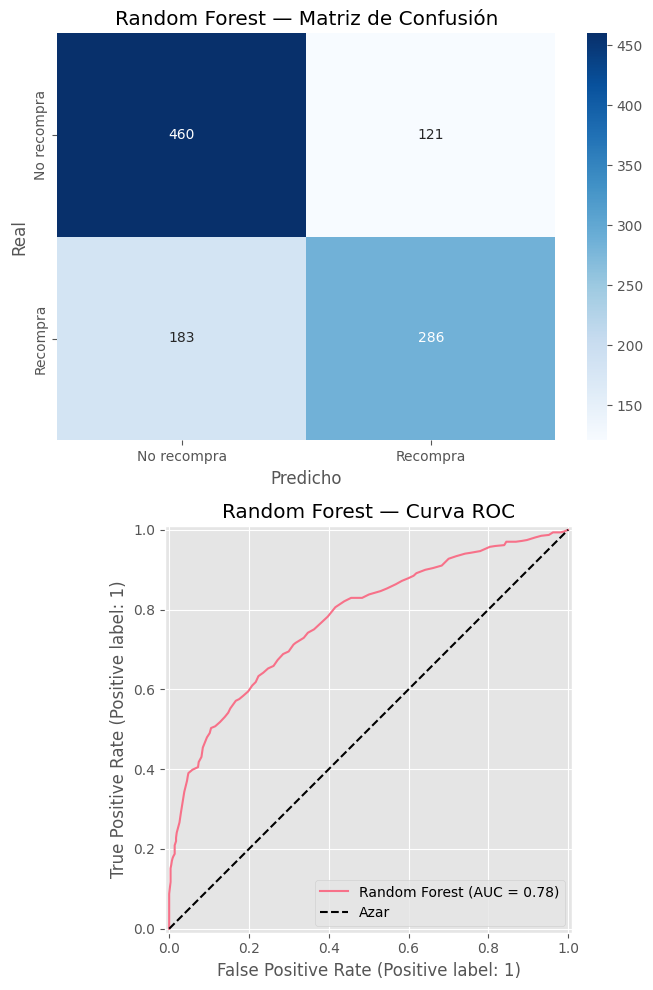

ROC-AUC Random Forest: 0.7760

Classification Report:
              precision    recall  f1-score   support

 No recompra       0.72      0.79      0.75       581
    Recompra       0.70      0.61      0.65       469

    accuracy                           0.71      1050
   macro avg       0.71      0.70      0.70      1050
weighted avg       0.71      0.71      0.71      1050



In [26]:
# ── Random Forest (sin Optuna) ────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_sc, y_train)

y_pred_rf      = model_rf.predict(X_test_sc)
y_pred_prob_rf = model_rf.predict_proba(X_test_sc)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_pred_prob_rf)

# Gráficas
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, axes = plt.subplots(2, 1, figsize=(7, 10))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No recompra', 'Recompra'],
            yticklabels=['No recompra', 'Recompra'])
axes[0].set_title('Random Forest — Matriz de Confusión')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

RocCurveDisplay.from_predictions(y_test, y_pred_prob_rf, ax=axes[1], name='Random Forest')
axes[1].set_title('Random Forest — Curva ROC')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'ROC-AUC Random Forest: {roc_auc_rf:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['No recompra', 'Recompra']))

#### Optimización con Optuna

Búsqueda inteligente sobre `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` y `min_samples_split` con 100 intentos y validación cruzada de 5 folds.

In [27]:
# ── (Opcional) Búsqueda de hiperparámetros con Optuna — Random Forest ──────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_rf(trial):
    # Hiperparámetros que Optuna va a explorar
    n_estimators     = trial.suggest_int('n_estimators', 50, 500)
    max_depth        = trial.suggest_int('max_depth', 3, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features     = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        min_samples_split=min_samples_split,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    # Validación cruzada de 5 folds — devuelve el ROC-AUC medio
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Crear el estudio y optimizar (n_trials = número de intentos)
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=100, show_progress_bar=True)

print(f'\nMejores hiperparámetros: {study_rf.best_params}')
print(f'Mejor ROC-AUC (CV):      {study_rf.best_value:.4f}')

# Evaluar el mejor modelo en test
best_rf = RandomForestClassifier(
    **study_rf.best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train_sc, y_train)
y_pred_rf_opt      = best_rf.predict(X_test_sc)
y_pred_prob_rf_opt = best_rf.predict_proba(X_test_sc)[:, 1]

roc_auc_rf_opt = roc_auc_score(y_test, y_pred_prob_rf_opt)
print(f'\nROC-AUC en test (Optuna): {roc_auc_rf_opt:.4f}')
print(f'ROC-AUC en test (base):   {roc_auc_rf:.4f}')
print('\nClassification Report (mejor modelo):')
print(classification_report(y_test, y_pred_rf_opt, target_names=['No recompra', 'Recompra']))

  0%|          | 0/100 [00:00<?, ?it/s]


Mejores hiperparámetros: {'n_estimators': 493, 'max_depth': 7, 'min_samples_leaf': 19, 'max_features': None, 'min_samples_split': 7}
Mejor ROC-AUC (CV):      0.8077

ROC-AUC en test (Optuna): 0.8046
ROC-AUC en test (base):   0.7760

Classification Report (mejor modelo):
              precision    recall  f1-score   support

 No recompra       0.75      0.74      0.74       581
    Recompra       0.68      0.69      0.69       469

    accuracy                           0.72      1050
   macro avg       0.71      0.71      0.71      1050
weighted avg       0.72      0.72      0.72      1050



### Modelo 3: XGBoost

Modelo de boosting: cada árbol nuevo corrige los errores del anterior. Generalmente el más potente en datasets tabulares como este.

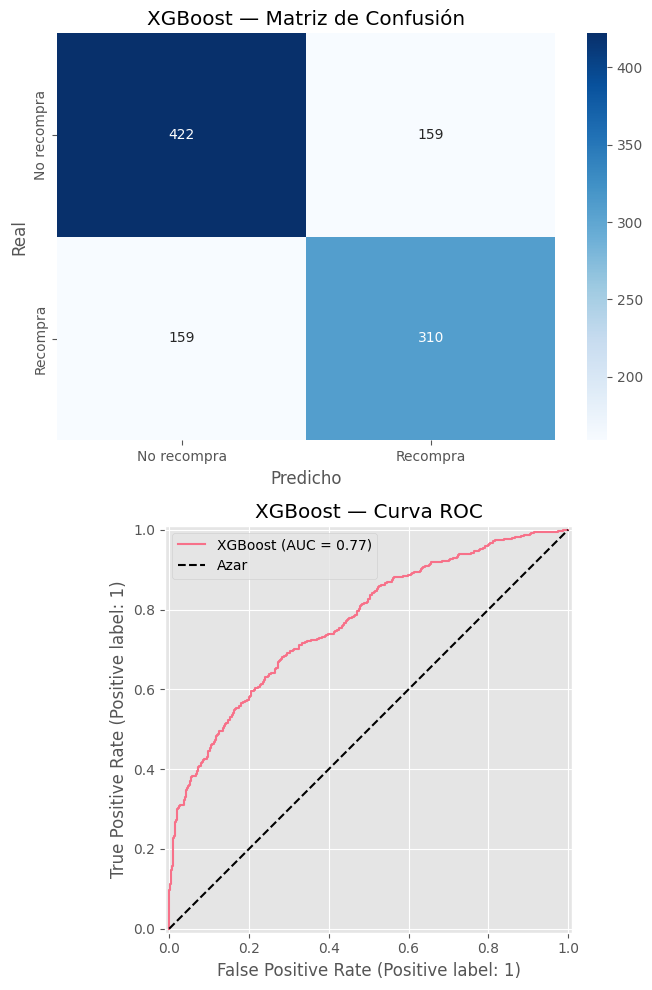

ROC-AUC XGBoost: 0.7677

Classification Report:
              precision    recall  f1-score   support

 No recompra       0.73      0.73      0.73       581
    Recompra       0.66      0.66      0.66       469

    accuracy                           0.70      1050
   macro avg       0.69      0.69      0.69      1050
weighted avg       0.70      0.70      0.70      1050



In [28]:
# ── XGBoost (sin Optuna) ──────────────────────────────────────────────────────
from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
model_xgb.fit(X_train_sc, y_train)

y_pred_xgb      = model_xgb.predict(X_test_sc)
y_pred_prob_xgb = model_xgb.predict_proba(X_test_sc)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_pred_prob_xgb)

# Gráficas
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fig, axes = plt.subplots(2, 1, figsize=(7, 10))

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No recompra', 'Recompra'],
            yticklabels=['No recompra', 'Recompra'])
axes[0].set_title('XGBoost — Matriz de Confusión')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

RocCurveDisplay.from_predictions(y_test, y_pred_prob_xgb, ax=axes[1], name='XGBoost')
axes[1].set_title('XGBoost — Curva ROC')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'ROC-AUC XGBoost: {roc_auc_xgb:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['No recompra', 'Recompra']))

#### Optimización con Optuna

Búsqueda inteligente sobre `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`, `reg_alpha` y `reg_lambda` con 100 intentos y validación cruzada de 5 folds.

In [29]:
# ── (Opcional) Búsqueda de hiperparámetros con Optuna — XGBoost ───────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_xgb(trial):
    # Hiperparámetros que Optuna va a explorar
    n_estimators      = trial.suggest_int('n_estimators', 50, 500)
    max_depth         = trial.suggest_int('max_depth', 3, 12)
    learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.3, log=True)
    subsample         = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    min_child_weight  = trial.suggest_int('min_child_weight', 1, 10)
    gamma             = trial.suggest_float('gamma', 0, 5)
    reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10, log=True)
    reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10, log=True)

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        scale_pos_weight=scale,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    )
    # Validación cruzada de 5 folds — devuelve el ROC-AUC medio
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Crear el estudio y optimizar (n_trials = número de intentos)
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

print(f'\nMejores hiperparámetros: {study_xgb.best_params}')
print(f'Mejor ROC-AUC (CV):      {study_xgb.best_value:.4f}')

# Evaluar el mejor modelo en test
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
best_xgb.fit(X_train_sc, y_train)
y_pred_xgb_opt      = best_xgb.predict(X_test_sc)
y_pred_prob_xgb_opt = best_xgb.predict_proba(X_test_sc)[:, 1]

roc_auc_xgb_opt = roc_auc_score(y_test, y_pred_prob_xgb_opt)
print(f'\nROC-AUC en test (Optuna): {roc_auc_xgb_opt:.4f}')
print(f'ROC-AUC en test (base):   {roc_auc_xgb:.4f}')
print('\nClassification Report (mejor modelo):')
print(classification_report(y_test, y_pred_xgb_opt, target_names=['No recompra', 'Recompra']))

  0%|          | 0/100 [00:00<?, ?it/s]


Mejores hiperparámetros: {'n_estimators': 397, 'max_depth': 6, 'learning_rate': 0.05405020774439876, 'subsample': 0.639406388127535, 'colsample_bytree': 0.7903715400065147, 'min_child_weight': 5, 'gamma': 4.192289677930081, 'reg_alpha': 0.7623216961294547, 'reg_lambda': 0.001175215507866477}
Mejor ROC-AUC (CV):      0.8099

ROC-AUC en test (Optuna): 0.7982
ROC-AUC en test (base):   0.7677

Classification Report (mejor modelo):
              precision    recall  f1-score   support

 No recompra       0.74      0.74      0.74       581
    Recompra       0.68      0.68      0.68       469

    accuracy                           0.71      1050
   macro avg       0.71      0.71      0.71      1050
weighted avg       0.71      0.71      0.71      1050



### Comparación final de modelos

Curva ROC con los tres modelos optimizados con Optuna en el mismo gráfico.  
Cuanto más arriba y a la izquierda esté la curva respecto a la diagonal, mejor discrimina el modelo.

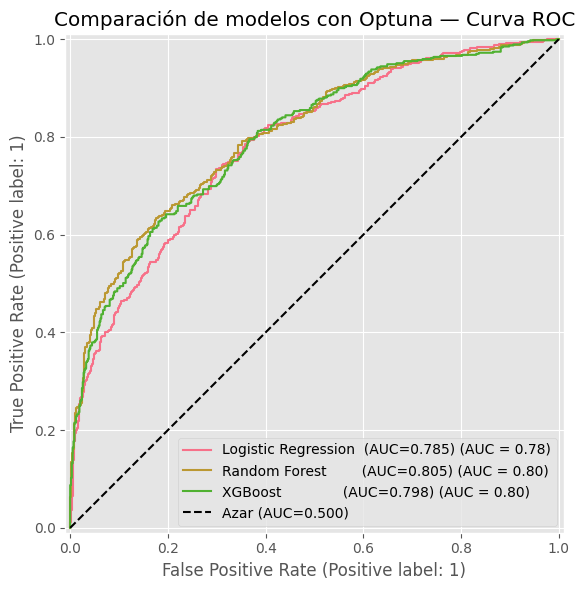

             Modelo  ROC-AUC
      Random Forest     0.80
            XGBoost     0.80
Logistic Regression     0.78


In [30]:
# ── Comparación final de modelos (con Optuna) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_pred_prob_best,    ax=ax, name=f'Logistic Regression  (AUC={roc_auc_best:.3f})')
RocCurveDisplay.from_predictions(y_test, y_pred_prob_rf_opt,  ax=ax, name=f'Random Forest        (AUC={roc_auc_rf_opt:.3f})')
RocCurveDisplay.from_predictions(y_test, y_pred_prob_xgb_opt, ax=ax, name=f'XGBoost              (AUC={roc_auc_xgb_opt:.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.500)')

ax.set_title('Comparación de modelos con Optuna — Curva ROC')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

resumen = pd.DataFrame({
    'Modelo':  ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [roc_auc_best, roc_auc_rf_opt, roc_auc_xgb_opt]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print(resumen.to_string(index=False))

## 9. Explicabilidad del modelo

Identificamos qué variables tienen más peso en la predicción.  
Usamos dos enfoques complementarios:
- **Coeficientes de Regresión Logística** → peso directo de cada variable (modelo lineal)
- **Feature Importance de XGBoost** → cuánto contribuye cada variable a reducir el error en los árboles

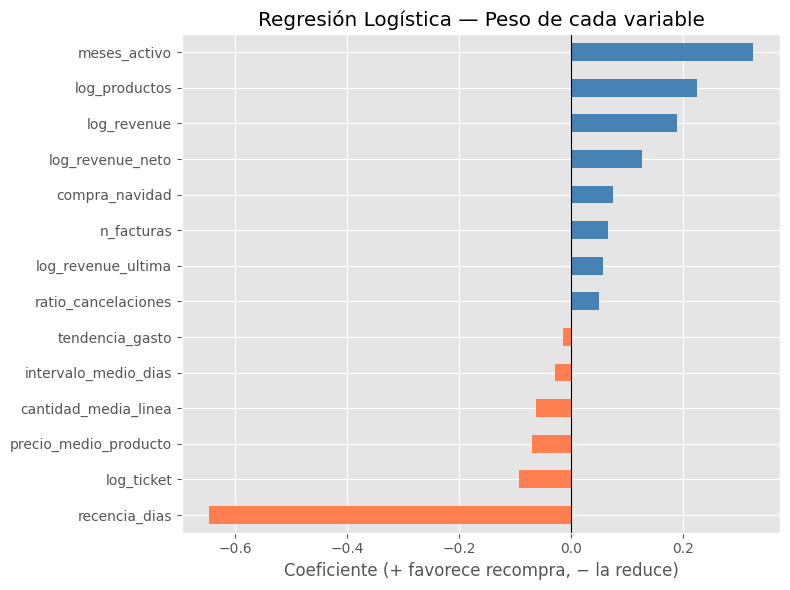


Interpretación:
  Variable que MÁS favorece recompra:  meses_activo (0.326)
  Variable que MÁS reduce recompra:    recencia_dias (-0.647)


In [31]:
# ── 9.1 Coeficientes de Regresión Logística ───────────────────────────────────
feature_names = list(X.columns)
coefs = pd.Series(best_model.coef_[0], index=feature_names)

# Mostrar solo features numéricas (excluir OHE de países)
coefs_num = coefs[FEATURES_FINAL].sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['coral' if v < 0 else 'steelblue' for v in coefs_num]
coefs_num.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Regresión Logística — Peso de cada variable')
ax.set_xlabel('Coeficiente (+ favorece recompra, − la reduce)')
plt.tight_layout()
plt.show()

print("\nInterpretación:")
print(f"  Variable que MÁS favorece recompra:  {coefs_num.idxmax()} ({coefs_num.max():.3f})")
print(f"  Variable que MÁS reduce recompra:    {coefs_num.idxmin()} ({coefs_num.min():.3f})")

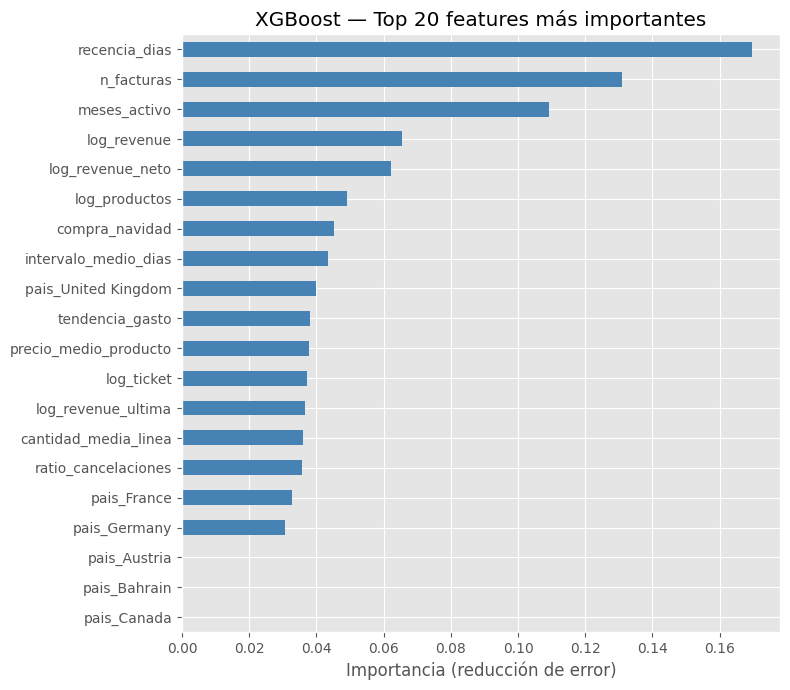


Top 10 features:
recencia_dias          0.17
n_facturas             0.13
meses_activo           0.11
log_revenue            0.07
log_revenue_neto       0.06
log_productos          0.05
compra_navidad         0.05
intervalo_medio_dias   0.04
pais_United Kingdom    0.04
tendencia_gasto        0.04


In [32]:
# ── 9.2 Feature Importance de XGBoost ────────────────────────────────────────
importances_xgb = pd.Series(
    best_xgb.feature_importances_,
    index=feature_names
)

# Top 20 features
top20 = importances_xgb.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost — Top 20 features más importantes')
ax.set_xlabel('Importancia (reducción de error)')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(top20.head(10).to_string())

### Conclusiones del modelo

**Resultados finales (modelos optimizados con Optuna):**

| Modelo | ROC-AUC (test) |
|--------|---------------|
| XGBoost | 0.80 |
| Random Forest | 0.80 |
| Logistic Regression | 0.78 |

**Interpretación de las variables más relevantes (según explicabilidad):**
- **`recencia_dias`** → cuanto más reciente fue la última compra, más probable es que el cliente vuelva
- **`n_facturas`** → clientes con más historial de compras tienen mayor fidelidad
- **`meses_activo`** → un cliente que compra en meses distintos es más fiel que uno que compró varias veces el mismo mes
- **`log_revenue`** → el gasto total acumulado es un buen predictor de intención futura
- **`intervalo_medio_dias`** → clientes con compras regulares tienen mayor probabilidad de recompra
- **`ratio_cancelaciones`** → clientes con muchas devoluciones tienen menor probabilidad de recompra

**Limitaciones del modelo:**
- Dataset limitado a ~5,000 clientes únicos con historial antes del corte
- Un ROC-AUC de 0.80 es un resultado sólido para este tipo de problema con los datos disponibles